Lugo Avalos Vanessa Aidee 6AV1

# Regresión Robusta
Técnica para la estimación de modelos de regresión donde se emplean métodos que reducen la influencia de observaciones atípicas y desviaciones del modelo de regresión lineal.
$$\hat{\beta} = argmin \sum_{i=1}^n \rho (\frac{y_i - X_i\beta}{\sigma})$$
$y_i$: Variable dependiente.    
$X_i$: Vector de predicciones para la observación $i$.    
$\beta$: Vector de coeficientes del modelo.   
$\sigma$: Parámetro de escala, usualmente es la desviación estándar de los residuos.   
$\rho$: Función de pérdida que pondera los residuos para que los valores atípicos tengan menos influencia en la estimación.

## Etimación de Huber
Técnica que modifica la función de pérdida de los mínimos cuadrados ordinarios (OLS), para valores pequeños se comporta como OLS ($$r^2$$) y para valores grandes usa función lineal para reducir el impacto de los valores atípicos.
$$\rho(r) = \begin{cases} \frac{1}{2}r^2; & \text{si } |r| \leq c \\c \left(|r| - \frac{1}{2}c\right); & \text{si } |r| > c \end{cases}$$

$c$: Parámetro de umbral que determina cuando un residuo es considerado grande.   
$|r| \leq c$: La función se comporta como mínimos cuadrados.   
$|r| > c$: La función es lineal, lo cual reduce el impacto de los valores extremos.   
$c$: Su valor suele tomarse como $1.345$ en la práctica.   

## Librerías.
Se importan las librerías necesarias. Numpy permite la maipulación de datos, matplotlib permite realizar grágicas, statsmodels.api es un módulo para la estimación

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sn
from sklearn.linear_model import HuberRegressor, LinearRegression
from sklearn.metrics import mean_squared_error,r2_score, mean_absolute_error

## Generación de 100 datos aleatorios.
Se generan 100 datos aleatorios usando la semilla 42, para definir los valores de X se usa np.random.rand para crear una matriz de  100 filas y 1 columna y se multiplican *10 para que estén uniformemente distribuidos. Para los valores de y_original se convierte la matriz de dos dimensiones a una dimensión, se general 100 datos aleatorios con distribución normal y desviación estándar de 2.

In [58]:
np.random.seed(42)
X = np.random.rand(100, 1) *10
y_original = 2.5 * X.squeeze() + np.random.randn(100) * 2

## Cambio de los últimos valores para que sean atípicos.
Se hacen valores de y atipicos, copiando los valores de y_originales y agregando 30 a los últimos 5 valores.

In [59]:
y_atipicos = y_original.copy()
y_atipicos[95:] += 30
print(y_atipicos)

[ 9.53759711 23.16984296 18.4833701  10.99132428  3.46112224  4.61408815
  4.40787839 20.61786321 13.41088809 16.69830036  2.34541659 24.90524852
 19.75154561  6.33501263  4.73977928  6.52240273  6.20194989 12.4635865
 10.01440916  4.35369861 15.88856292  4.00945706  7.31384313  8.68987182
  8.57100812 18.78810839  4.30641552 11.25130642 14.4877928   1.96936203
 18.9609931   4.61225872  2.14139061 23.5732466  20.3032584  20.15690595
  7.73580465  7.36828708 16.72110373 11.60690703  2.98153233 10.04206668
  3.14535866 24.23687612  8.05156343 14.7442822  10.59836552 10.1979984
 14.84147117  9.00227264 22.25854304 18.24572512 23.68677627 21.36373245
 11.84617261 23.18398183  0.08770512  5.84675642 -0.70816625 11.23312708
  8.15042566  6.13960276 22.34547216  6.45710453  7.47828261 16.18168759
  0.30813916 20.42419224  2.38353168 26.23581916 16.83221781  2.32697881
  1.18193606 20.98050506 18.1724193  18.91807562 17.92170922  2.31562369
  9.54778816  1.46802365 25.30913467 16.53011901  5.8

## Regresión robusta Huber.
Se entrena el modelo de regresión robusta, manda a llamar la clase de HuberRegressor con el parámetro de del epsilon, el cual es el valor de c de la formula. Después, se llama a método para entrenar al modelo. Se entrena usando los valores de la variable independiente X, y los valores de Y con datos atípicos.

In [60]:
huber = HuberRegressor(epsilon = 1.35)
huber.fit(X, y_atipicos)

,epsilon,1.35
,max_iter,100
,alpha,0.0001
,warm_start,False
,fit_intercept,True
,tol,1e-05


### Interpolación de los valores de X.
Se hace la interpolación de los valores de X. Se toma el valor mínimo y el valor máximo y se generan 100 valores distribuidos de manera uniforme, finalmente, se convierte en una matriz de 100 filas y una columna para que pueda ser aceptado para hacer las predicciones de y.

In [61]:
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

### Predicciones de Y con regresión robusta Huber.

Se calculan los valores para las predicciones de Y, usando el método predict de la librería y pasando los valores de la interpolación de X.

In [62]:
y_pred_huber = huber.predict(X_range)
y_pred_huber_all = huber.predict(X)

### Errores
MSE: Mean Squared Error (Error cuadrático medio).    
$$MSE = \frac{1}{n} \sum_{i = 1}^n (y_i - \hat{y_i})^2$$   

RMSE: Root Mean Squared Error (Raíz del error cuadrático medio).   
$$RMSE = \sqrt{MSE}$$     
   
$R^2$: Coeficiente de determinación.    
$$R^2 = 1-\frac{\sum(\hat{y_i} - \bar{y_i})^2}{\sum (y_i - \bar{y_i})}$$

In [63]:
rmse_huber = np.sqrt(mean_squared_error(y_atipicos, y_pred_huber_all))
r2_huber = r2_score(y_atipicos, y_pred_huber_all)

print(f' RMSE Huber = {rmse_huber}')
print(f' r2 huber = {r2_huber}')

 RMSE Huber = 6.934184060327409
 r2 huber = 0.43990405649246456


## Regresión lineal.
Se manda a llamar la clase de LinearRegression y el método fit para entrenar al modelo. Se entrena usando los valores de la variable X y los valores de la variable Y con valores atípicos.

In [64]:
modelo = LinearRegression()
modelo.fit(X_range, y_atipicos)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Predicciones de Y con regresión lineal.
Se hace el calculo de $b_0$ y de $b_1$ para obtener los valores para la predicción de Y.
$$\hat{b_1} = \frac{\sum_{i =1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i =1}^n (x_i - \bar{x})^2}$$    
$$\hat{b_0} = \bar{y} - \hat{b_1}\bar{x}$$
$$\hat{y} = \hat{b_0} + \hat{b_1} x$$

In [65]:
b0 = modelo.intercept_
b1= modelo.coef_[0]
y_pred_lineal = b0 + b1 * X

### Métricas para regresión lineal.

In [66]:
rmse_lineal = np.sqrt(mean_squared_error(y_atipicos, y_pred_lineal))
r2_lineal = r2_score(y_atipicos, y_pred_lineal)

print(f' RMSE Huber = {rmse_huber}')
print(f' r2 huber = {r2_huber}')

 RMSE Huber = 6.934184060327409
 r2 huber = 0.43990405649246456


## Gráfica de datos originales sin valores atípicos.
Se grafican de color azul cada dato del conjunto de datos establecido por 100 valores aleatorios. 

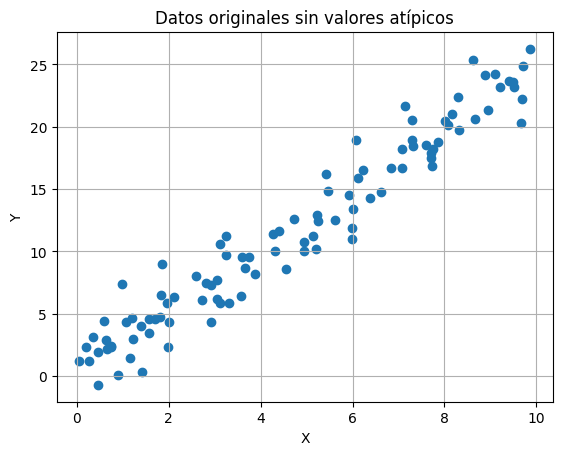

In [67]:
plt.scatter(X, y_original)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Datos originales sin valores atípicos')
plt.grid(True)
plt.show()

## Gráfica de datos originales con valores atípicos.
Se grafican de color rojo los datos representados por puntos, esta vez, se usan los valores con datos atípicos.

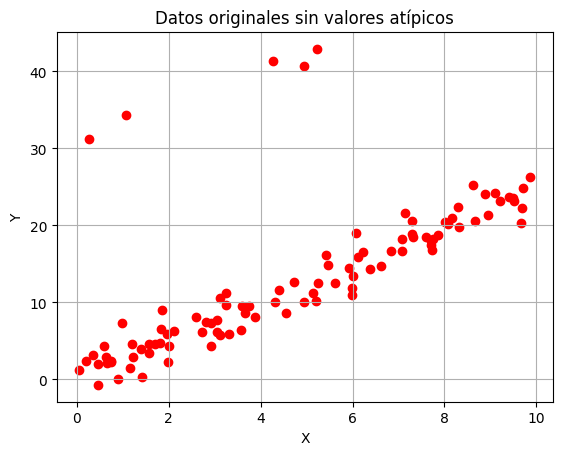

In [68]:
plt.scatter(X, y_atipicos, color = 'red')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Datos originales sin valores atípicos')
plt.grid(True)
plt.show()

## Gráfica de regresión lineal con valores atípicos.
Se realiza una gráfica mostrando con puntos de color rojo a los datos con valores atípicos, y la recta de la regresión lineal de color azul.

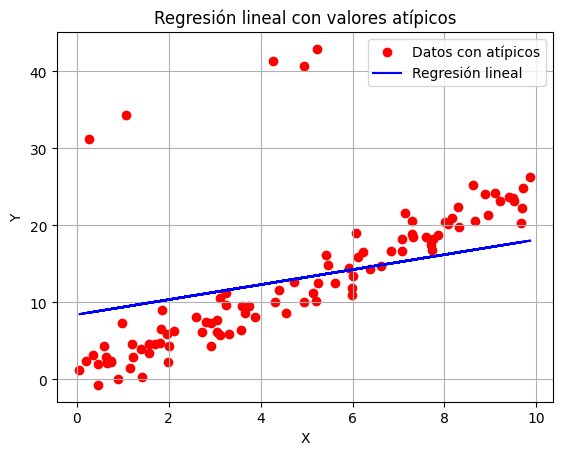

In [69]:
plt.scatter(X, y_atipicos, color = 'red', label = 'Datos con atípicos')
plt.plot(X, y_pred_lineal, color = 'blue', label = 'Regresión lineal')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Regresión lineal con valores atípicos')
plt.grid(True)
plt.legend()
plt.show()

## Gráfica de regresión Huber con valores atípicos. 
Se realiza una gráfica mostrando con puntos de color rojo a los datos con valores atípicos, y la recta de la regresión robusta Huber con una línea interrumpida de color azul.

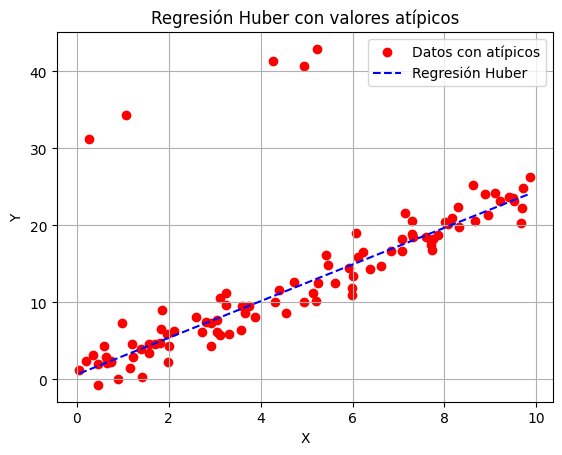

In [70]:
plt.scatter(X, y_atipicos, color = 'red', label = 'Datos con atípicos')
plt.plot(X_range, y_pred_huber, color = 'blue', label = 'Regresión Huber', linestyle = '--')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Regresión Huber con valores atípicos')
plt.grid(True)
plt.legend()
plt.show()

## Gráfica de regresión lineal vs regresión 
Se realiza una gráfica mostrando con puntos de color amarillo a los datos con valores atípicos, la recta de la regresión lineal de color azul, y la recta de la regresión robusta Huber con una línea interrumpida de color rojo.

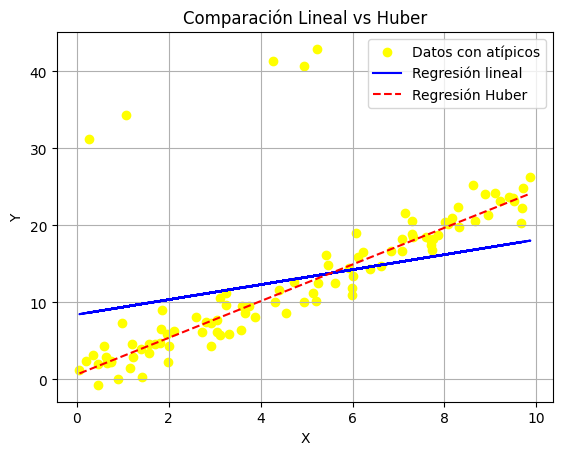

Comparación regresión linal vs regresión Huber
 RMSE Huber = 6.934184060327409, r2 huber = 0.43990405649246456
 RMSE lineal = 7.593666049166177, r2 lineal = 0.3283010264349341


In [71]:
plt.scatter(X, y_atipicos, color = 'yellow', label = 'Datos con atípicos')
plt.plot(X, y_pred_lineal, color = 'blue', label = 'Regresión lineal')
plt.plot(X_range, y_pred_huber, color = 'red', label = 'Regresión Huber', linestyle = '--')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Comparación Lineal vs Huber')
plt.grid(True)
plt.legend()
plt.show()

print('Comparación regresión linal vs regresión Huber')
print(f' RMSE Huber = {rmse_huber}, r2 huber = {r2_huber}')
print(f' RMSE lineal = {rmse_lineal}, r2 lineal = {r2_lineal}')

## Conclusión
Como conclusión, la regresión de Huber presenta un mayor valor en el coeficiente de determinación, el cual es mayor pues vale 0.4 en comparación con con el coeficiente de determinación lineal con un valor de 0.32. Por esto, la regresión de Huber tiene mayor ajuste a los datos. Además, el valor de RMSE de Huber es menor al RMSE de la regresión lineal. 